Run locally or <a target="_blank" href="https://colab.research.google.com/github/aalgahmi/dl_handouts/blob/main/19.graph_neural_networks.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [1]:
%%capture
!pip install -q torch-geometric
!pip install -q networkx

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import lightning as L
from torchinfo import summary
from torchmetrics import Accuracy

/Users/aalgahmi/torch/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Graph Neural Networks (GNNs)

So far in this course, we have explored deep learning models that operate on regular, grid-like data structures: fully connected networks process flat feature vectors, convolutional neural networks work with images arranged on 2D grids, and recurrent neural networks handle sequences (1D chains). However, many real-world datasets are naturally represented as **graphs** — irregular structures consisting of nodes (entities) and edges (relationships). Social networks, molecules, citation networks, transportation systems, and knowledge graphs are all examples of graph-structured data.

Graph Neural Networks (GNNs) extend deep learning to handle these non-Euclidean data structures. The central idea behind GNNs is the **message passing** paradigm: each node iteratively updates its representation by aggregating information from its neighbors. This allows GNNs to learn node-level, edge-level, and graph-level representations that capture both the features of individual entities and the structure of their relationships.

In this notebook, we will explore the fundamentals of GNNs using [PyTorch Geometric (PyG)](https://pytorch-geometric.readthedocs.io/), a popular library built on top of PyTorch for deep learning on graphs. We will cover graph representations, key GNN architectures (GCN, GAT, GraphSAGE), and work through examples of both node classification and graph classification tasks.

## Graphs: A Quick Review

A graph $G = (V, E)$ consists of a set of **nodes** (or vertices) $V = \{v_1, v_2, \ldots, v_n\}$ and a set of **edges** $E \subseteq V \times V$. Each edge $(v_i, v_j) \in E$ represents a connection between nodes $v_i$ and $v_j$.

Graphs can be:
- **Undirected**: edges have no direction, i.e., $(v_i, v_j) = (v_j, v_i)$
- **Directed**: edges have a direction, i.e., $(v_i, v_j) \neq (v_j, v_i)$
- **Weighted**: edges carry numerical values representing the strength of connections

A graph is typically represented by an **adjacency matrix** $\mathbf{A} \in \{0, 1\}^{n \times n}$, where $A_{ij} = 1$ if there is an edge from $v_i$ to $v_j$, and $0$ otherwise. In addition, each node may carry a **feature vector** $\mathbf{x}_i \in \mathbb{R}^d$, and all node features are stacked into a **feature matrix** $\mathbf{X} \in \mathbb{R}^{n \times d}$.

### Graphs in PyTorch Geometric

PyTorch Geometric (PyG) represents graphs using the `torch_geometric.data.Data` object. Instead of storing the full adjacency matrix (which is often sparse and memory-inefficient), PyG uses a **COO (Coordinate) format** called `edge_index` — a tensor of shape `[2, num_edges]` where each column represents an edge.

Let's create a simple graph to understand this representation.

In [3]:
from torch_geometric.data import Data

# A simple undirected graph with 4 nodes and 4 edges
# Node features: each node has a 3-dimensional feature vector
x = torch.tensor([
    [1.0, 0.0, 0.0],  # Node 0
    [0.0, 1.0, 0.0],  # Node 1
    [0.0, 0.0, 1.0],  # Node 2
    [1.0, 1.0, 0.0],  # Node 3
])

# Edge index in COO format [source_nodes, target_nodes]
# For undirected graphs, each edge is stored in both directions
edge_index = torch.tensor([
    [0, 1, 1, 2, 2, 3, 3, 0],  # source nodes
    [1, 0, 2, 1, 3, 2, 0, 3],  # target nodes
], dtype=torch.long)

# Create the graph data object
data = Data(x=x, edge_index=edge_index)
print(data)
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.num_edges}")
print(f"Number of node features: {data.num_node_features}")
print(f"Is undirected: {data.is_undirected()}")

Data(x=[4, 3], edge_index=[2, 8])
Number of nodes: 4
Number of edges: 8
Number of node features: 3
Is undirected: True


Let's visualize this graph using NetworkX.

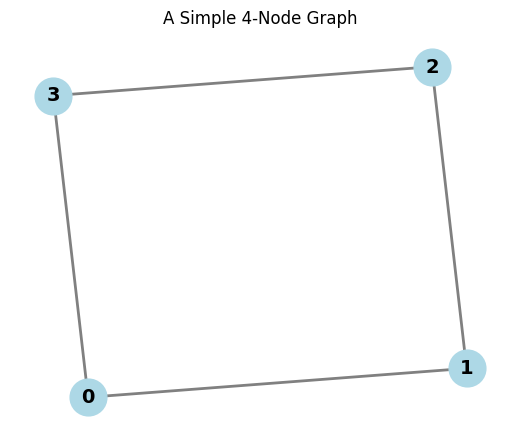

In [4]:
import networkx as nx
from torch_geometric.utils import to_networkx

G = to_networkx(data, to_undirected=True)

plt.figure(figsize=(5, 4))
nx.draw(G, with_labels=True, node_color='lightblue', node_size=700,
        font_size=14, font_weight='bold', edge_color='gray', width=2)
plt.title("A Simple 4-Node Graph")
plt.show()

## The Message Passing Framework

The key idea behind most GNN architectures is **message passing** (also called neighborhood aggregation). At each layer $l$, every node $v$ updates its representation by:

1. **Gathering messages** from its neighbors $\mathcal{N}(v)$
2. **Aggregating** those messages (e.g., sum, mean, or max)
3. **Updating** its own representation using the aggregated message

Formally, the update rule at layer $l$ can be written as:

$$\mathbf{h}_v^{(l)} = \text{UPDATE}^{(l)}\left(\mathbf{h}_v^{(l-1)},\; \text{AGGREGATE}^{(l)}\left(\{\mathbf{h}_u^{(l-1)} : u \in \mathcal{N}(v)\}\right)\right)$$

where $\mathbf{h}_v^{(0)} = \mathbf{x}_v$ (the initial node features), and different GNN architectures differ in how they define the AGGREGATE and UPDATE functions.

After $K$ layers of message passing, each node's representation $\mathbf{h}_v^{(K)}$ encodes information from its $K$-hop neighborhood — that is, all nodes that are at most $K$ edges away.

## Graph Convolutional Networks (GCNs)

The Graph Convolutional Network (GCN), introduced by Kipf and Welling (2017), is one of the most foundational GNN architectures. The GCN layer computes the new representation of a node by taking a **normalized, weighted sum** of its neighbors' features (including its own via a self-loop).

The update rule for a GCN layer is:

$$\mathbf{h}_v^{(l)} = \sigma\left(\sum_{u \in \mathcal{N}(v) \cup \{v\}} \frac{1}{\sqrt{\hat{d}_v \hat{d}_u}} \mathbf{W}^{(l)} \mathbf{h}_u^{(l-1)}\right)$$

where:
- $\mathbf{W}^{(l)}$ is a learnable weight matrix for layer $l$
- $\hat{d}_v = d_v + 1$ is the degree of node $v$ plus 1 (accounting for the self-loop)
- $\sigma$ is an activation function (typically ReLU)
- The normalization factor $\frac{1}{\sqrt{\hat{d}_v \hat{d}_u}}$ prevents node representations from growing in magnitude as they aggregate from neighborhoods of varying size

In matrix form, this can be written compactly as:

$$\mathbf{H}^{(l)} = \sigma\left(\hat{\mathbf{D}}^{-1/2} \hat{\mathbf{A}} \hat{\mathbf{D}}^{-1/2} \mathbf{H}^{(l-1)} \mathbf{W}^{(l)}\right)$$

where $\hat{\mathbf{A}} = \mathbf{A} + \mathbf{I}$ is the adjacency matrix with self-loops and $\hat{\mathbf{D}}$ is the corresponding degree matrix.

## Node Classification on the Cora Dataset

Let's now work through a concrete example. We will perform **node classification** on the **Cora** citation network dataset. In Cora:

- Each **node** represents a scientific paper (2,708 papers total)
- Each **edge** represents a citation link between papers (10,556 edges)
- Each node has a **feature vector** of 1,433 dimensions (bag-of-words representation)
- Each node belongs to one of **7 classes** (research topics)

The task is to predict the research topic of each paper based on its features and its citation connections.

Let's start by loading and exploring the dataset.

In [5]:
from torch_geometric.datasets import Planetoid

dataset = Planetoid(root='./datasets', name='Cora')

print(f"Dataset: {dataset}")
print(f"Number of graphs: {len(dataset)}")
print(f"Number of features: {dataset.num_features}")
print(f"Number of classes: {dataset.num_classes}")

Dataset: Cora()
Number of graphs: 1
Number of features: 1433
Number of classes: 7


Since Cora is a single graph, the dataset contains just one `Data` object. Let's examine it.

In [6]:
data = dataset[0]

print(data)
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.num_edges}")
print(f"Average node degree: {data.num_edges / data.num_nodes:.2f}")
print(f"Number of training nodes: {data.train_mask.sum()}")
print(f"Number of validation nodes: {data.val_mask.sum()}")
print(f"Number of test nodes: {data.test_mask.sum()}")
print(f"Is undirected: {data.is_undirected()}")

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])
Number of nodes: 2708
Number of edges: 10556
Average node degree: 3.90
Number of training nodes: 140
Number of validation nodes: 500
Number of test nodes: 1000
Is undirected: True


**NOTICE THAT** the Cora dataset comes with predefined `train_mask`, `val_mask`, and `test_mask` boolean tensors that indicate which nodes belong to the training, validation, and test sets, respectively. This is called a **transductive** setting — all nodes are present in the graph during training, but we only use labels from the training nodes to learn, and then evaluate on the held-out nodes.

Let's visualize a portion of the Cora graph to get a sense of its structure.

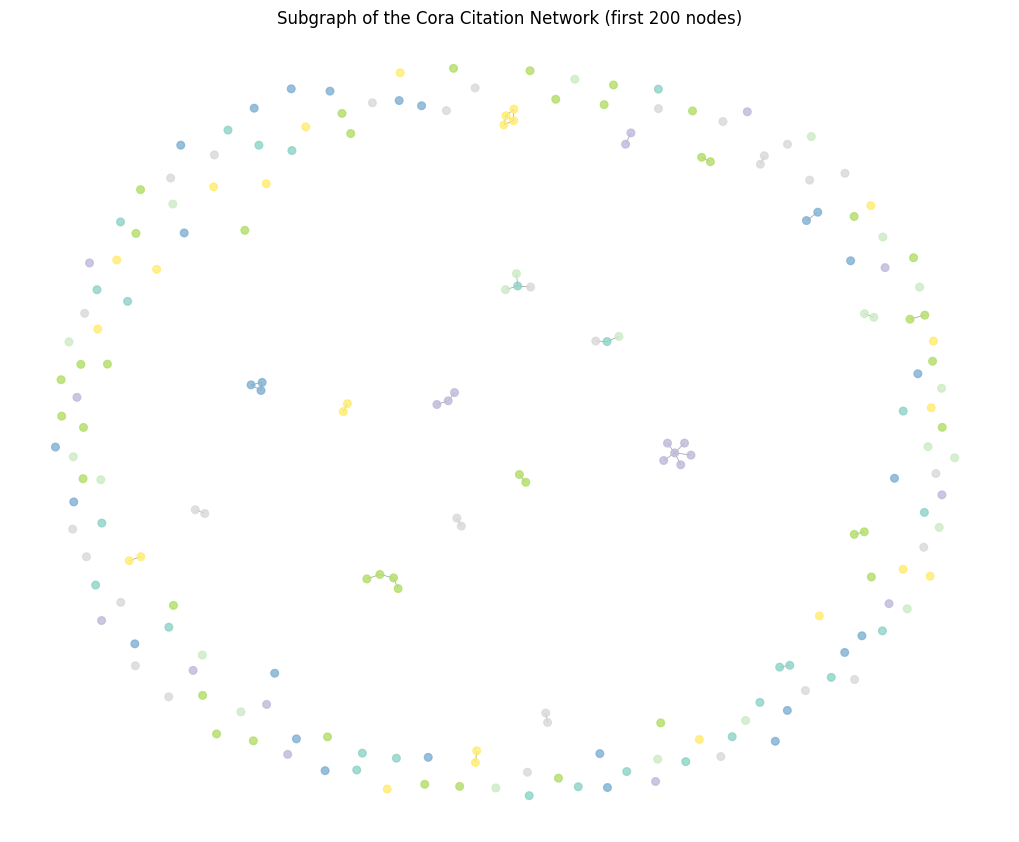

In [7]:
from torch_geometric.utils import to_networkx

# Convert to NetworkX for visualization (use a subgraph for clarity)
G = to_networkx(data, to_undirected=True)

plt.figure(figsize=(10, 8))
# Use only a subset of nodes for a cleaner plot
sub_nodes = list(range(200))
sub_G = G.subgraph(sub_nodes)

node_colors = [data.y[n].item() for n in sub_nodes]

pos = nx.spring_layout(sub_G, seed=42)
nx.draw(sub_G, pos, node_color=node_colors, cmap=plt.cm.Set3,
        node_size=30, edge_color='gray', alpha=0.8, width=0.5)
plt.title("Subgraph of the Cora Citation Network (first 200 nodes)")
plt.show()

The colors represent different research topics. Notice how nodes of the same color tend to cluster together — this is the **homophily** property (connected nodes tend to share the same label), which is what makes GNNs effective for this task.

### The Base Module

As we have done in previous notebooks, let's create a base Lightning module that will hold all the shared training, validation, and test logic. Each GNN model we build will subclass this base.

In [8]:
class BaseGNNModule(L.LightningModule):
    def __init__(self, lr=0.01, weight_decay=5e-4):
        super().__init__()
        self.lr = lr
        self.weight_decay = weight_decay
        self.train_accuracy = Accuracy(task="multiclass", num_classes=dataset.num_classes)
        self.val_accuracy = Accuracy(task="multiclass", num_classes=dataset.num_classes)
        self.test_accuracy = Accuracy(task="multiclass", num_classes=dataset.num_classes)

    def _common_step(self, data, mask, accuracy, loss_lbl, accuracy_lbl):
        logits = self(data)
        loss = F.cross_entropy(logits[mask], data.y[mask])
        y_hat = logits[mask].argmax(dim=-1)
        self.log(loss_lbl, loss, prog_bar=True, batch_size=mask.sum())
        self.log(accuracy_lbl, accuracy(y_hat, data.y[mask]), prog_bar=True, batch_size=mask.sum())
        return loss

    def training_step(self, batch, batch_idx):
        return self._common_step(batch, batch.train_mask, self.train_accuracy, "loss", "accuracy")

    def on_train_epoch_end(self):
        self.log("train_accuracy", self.train_accuracy.compute())
        self.train_accuracy.reset()

    def validation_step(self, batch, batch_idx):
        return self._common_step(batch, batch.val_mask, self.val_accuracy, "val_loss", "val_accuracy")

    def on_validation_epoch_end(self):
        self.log("val_accuracy_epoch", self.val_accuracy.compute())
        self.val_accuracy.reset()

    def test_step(self, batch, batch_idx):
        return self._common_step(batch, batch.test_mask, self.test_accuracy, "test_loss", "test_accuracy")

    def on_test_epoch_end(self):
        self.log("test_accuracy", self.test_accuracy.compute())
        self.test_accuracy.reset()

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr, weight_decay=self.weight_decay)

We also need a Lightning DataModule. Since Cora is a single graph, each "batch" is the entire graph. We use PyG's `DataLoader` for this.

In [9]:
from torch_geometric.loader import DataLoader as PyGDataLoader

class CoraDataModule(L.LightningDataModule):
    def __init__(self, data_path='./datasets'):
        super().__init__()
        self.data_path = data_path

    def prepare_data(self):
        Planetoid(root=self.data_path, name='Cora')

    def setup(self, stage=None):
        dataset = Planetoid(root=self.data_path, name='Cora')
        self.data = dataset[0]

    def train_dataloader(self):
        return PyGDataLoader([self.data], batch_size=1)

    def val_dataloader(self):
        return PyGDataLoader([self.data], batch_size=1)

    def test_dataloader(self):
        return PyGDataLoader([self.data], batch_size=1)

cora_dm = CoraDataModule()

### GCN Model

Let's build our first GNN model using the `GCNConv` layer from PyTorch Geometric. This is a two-layer GCN with dropout for regularization.

In [10]:
from torch_geometric.nn import GCNConv

class GCNModel(BaseGNNModule):
    def __init__(self, num_features, num_hidden, num_classes, dropout=0.5, lr=0.01, weight_decay=5e-4):
        super().__init__(lr=lr, weight_decay=weight_decay)
        self.dropout = dropout
        self.conv1 = GCNConv(num_features, num_hidden)
        self.conv2 = GCNConv(num_hidden, num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

gcn_model = GCNModel(
    num_features=dataset.num_features,
    num_hidden=16,
    num_classes=dataset.num_classes
)
print(gcn_model)

GCNModel(
  (train_accuracy): MulticlassAccuracy()
  (val_accuracy): MulticlassAccuracy()
  (test_accuracy): MulticlassAccuracy()
  (conv1): GCNConv(1433, 16)
  (conv2): GCNConv(16, 7)
)


Let's summarize the model architecture.

In [11]:
# Print model parameters
total_params = sum(p.numel() for p in gcn_model.parameters())
trainable_params = sum(p.numel() for p in gcn_model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 23,063
Trainable parameters: 23,063


We are now ready to train this GCN model.

In [12]:
trainer = L.Trainer(max_epochs=100, accelerator="gpu" if torch.cuda.is_available() else "cpu", devices=1)
trainer.fit(model=gcn_model, datamodule=cora_dm)

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/aalgahmi/torch/lib/python3.13/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/aalgahmi/torch/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default

  | Name           | Type               | 

/Users/aalgahmi/torch/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/Users/aalgahmi/torch/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/Users/aalgahmi/torch/lib/python3.13/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 0: 100%|█| 1/1 [00:00<00:00, 137.69it/s, v_num=14, loss=1.950, accuracy=0.
Validation: |                                             | 0/? [00:00<?, ?it/s]
Validation DataLoader 0: 100%|███████████████████| 1/1 [00:00<00:00, 233.91it/s]
Epoch 1: 100%|█| 1/1 [00:00<00:00, 195.86it/s, v_num=14, loss=1.850, accuracy=0.
Validation: |                                             | 0/? [00:00<?, ?it/s]
Validation DataLoader 0: 100%|███████████████████| 1/1 [00:00<00:00, 278.25it/s]
Epoch 2: 100%|█| 1/1 [00:00<00:00, 219.98it/s, v_num=14, loss=1.720, accuracy=0.
Validation: |                                             | 0/? [00:00<?, ?it/s]
Validation DataLoader 0: 100%|███████████████████| 1/1 [00:00<00:00, 273.90it/s]
Epoch 3: 100%|█| 1/1 [00:00<00:00, 197.23it/s, v_num=14, loss=1.560, accuracy=0.
Validation: |                                             | 0/? [00:00<?, ?it/s]
Validation DataLoader 0: 100%|███████████████████| 1/1 [00:00<00:00, 264.27it/s]
Epoch 4: 100%|█| 1/1 [00:00<

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|█| 1/1 [00:00<00:00, 63.31it/s, v_num=14, loss=0.0447, accuracy=0


Let's evaluate the GCN model on the test set.

In [13]:
trainer.test(gcn_model, datamodule=cora_dm)

/Users/aalgahmi/torch/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████████████████| 1/1 [00:00<00:00, 232.13it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      test_accuracy         0.7900000214576721
        test_loss           0.6422033309936523
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.6422033309936523, 'test_accuracy': 0.7900000214576721}]

Let's also plot the learning curves.

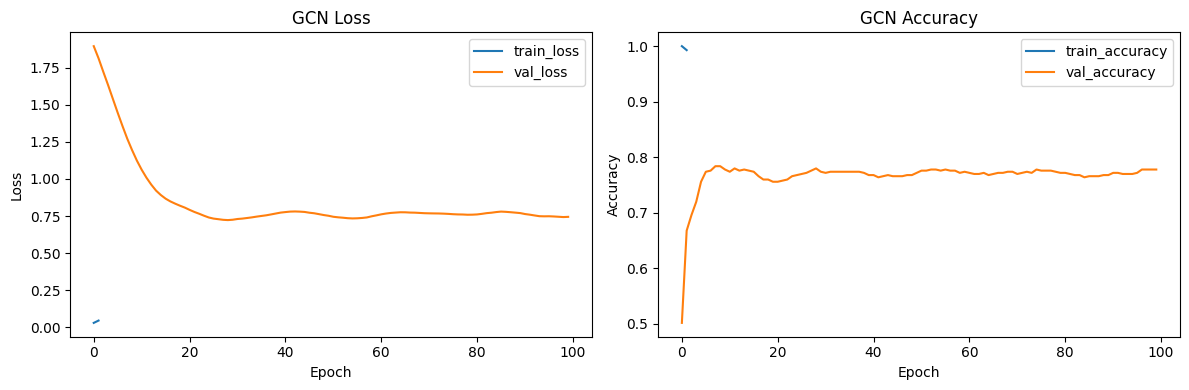

In [14]:
metrics = pd.read_csv(f"{trainer.logger.log_dir}/metrics.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot loss
axes[0].plot(metrics["loss"].dropna().values, label="train_loss")
axes[0].plot(metrics["val_loss"].dropna().values, label="val_loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].set_title("GCN Loss")

# Plot accuracy
axes[1].plot(metrics["accuracy"].dropna().values, label="train_accuracy")
axes[1].plot(metrics["val_accuracy"].dropna().values, label="val_accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].set_title("GCN Accuracy")

plt.tight_layout()
plt.show()

## Graph Attention Networks (GATs)

While GCN uses fixed normalization weights based on node degrees, **Graph Attention Networks (GATs)**, introduced by Veličković et al. (2018), learn to assign different **attention weights** to different neighbors. This allows the model to focus more on the most relevant neighbors for each node.

The attention coefficient between nodes $v$ and $u$ at layer $l$ is computed as:

$$e_{vu}^{(l)} = \text{LeakyReLU}\left(\mathbf{a}^{(l)T} [\mathbf{W}^{(l)} \mathbf{h}_v^{(l-1)} \| \mathbf{W}^{(l)} \mathbf{h}_u^{(l-1)}]\right)$$

where $\|$ denotes concatenation and $\mathbf{a}^{(l)}$ is a learnable attention vector. These coefficients are then normalized across all neighbors using softmax:

$$\alpha_{vu}^{(l)} = \frac{\exp(e_{vu}^{(l)})}{\sum_{k \in \mathcal{N}(v) \cup \{v\}} \exp(e_{vk}^{(l)})}$$

The new node representation is then a weighted sum:

$$\mathbf{h}_v^{(l)} = \sigma\left(\sum_{u \in \mathcal{N}(v) \cup \{v\}} \alpha_{vu}^{(l)} \mathbf{W}^{(l)} \mathbf{h}_u^{(l-1)}\right)$$

GAT also supports **multi-head attention**, where $K$ independent attention mechanisms are applied in parallel and their outputs are concatenated (or averaged in the final layer):

$$\mathbf{h}_v^{(l)} = \Big\|_{k=1}^{K} \sigma\left(\sum_{u \in \mathcal{N}(v)} \alpha_{vu}^{(l,k)} \mathbf{W}^{(l,k)} \mathbf{h}_u^{(l-1)}\right)$$

### GAT Model

Let's build a GAT model using the `GATConv` layer from PyTorch Geometric and train it on the same Cora dataset.

In [15]:
from torch_geometric.nn import GATConv

class GATModel(BaseGNNModule):
    def __init__(self, num_features, num_hidden, num_classes, heads=8, dropout=0.6, lr=0.005, weight_decay=5e-4):
        super().__init__(lr=lr, weight_decay=weight_decay)
        self.dropout = dropout
        # First GAT layer: multi-head attention
        self.conv1 = GATConv(num_features, num_hidden, heads=heads, dropout=dropout)
        # Second GAT layer: single-head attention for output
        self.conv2 = GATConv(num_hidden * heads, num_classes, heads=1, concat=False, dropout=dropout)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

gat_model = GATModel(
    num_features=dataset.num_features,
    num_hidden=8,
    num_classes=dataset.num_classes
)
print(gat_model)

total_params = sum(p.numel() for p in gat_model.parameters())
print(f"\nTotal parameters: {total_params:,}")

GATModel(
  (train_accuracy): MulticlassAccuracy()
  (val_accuracy): MulticlassAccuracy()
  (test_accuracy): MulticlassAccuracy()
  (conv1): GATConv(1433, 8, heads=8)
  (conv2): GATConv(64, 7, heads=1)
)

Total parameters: 92,373


**NOTICE THAT** the first GAT layer uses 8 attention heads, each producing an 8-dimensional output. These are concatenated, resulting in a 64-dimensional output ($8 \times 8 = 64$). The second layer uses a single head (with `concat=False`) to produce the final 7-class logits.

Let's train this GAT model.

In [16]:
trainer_gat = L.Trainer(max_epochs=100, accelerator="gpu" if torch.cuda.is_available() else "cpu", devices=1)
trainer_gat.fit(model=gat_model, datamodule=cora_dm)

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/aalgahmi/torch/lib/python3.13/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name           | Type               | Params | Mode 
--------------------------------------------------------------
0 | train_accuracy | MulticlassAccuracy | 0      | train
1 | val_accuracy   | MulticlassAccuracy | 0      | train
2 | test_accuracy  | MulticlassAccuracy | 0      | train
3 | conv1          | GATConv            | 91.9 K | train
4 | conv2          | GATConv            | 469    | train
--------------------------------------------------------------
92.4 K    Trainable params
0         Non-trainable params
92.4 K    Total params
0.369     Total estimated mo

/Users/aalgahmi/torch/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/Users/aalgahmi/torch/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/Users/aalgahmi/torch/lib/python3.13/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 0: 100%|█| 1/1 [00:00<00:00, 52.66it/s, v_num=15, loss=2.030, accuracy=0.1
Validation: |                                             | 0/? [00:00<?, ?it/s]
Validation DataLoader 0: 100%|███████████████████| 1/1 [00:00<00:00, 122.90it/s]
Epoch 1: 100%|█| 1/1 [00:00<00:00, 67.09it/s, v_num=15, loss=1.910, accuracy=0.2
Validation: |                                             | 0/? [00:00<?, ?it/s]
Validation DataLoader 0: 100%|███████████████████| 1/1 [00:00<00:00, 168.74it/s]
Epoch 2: 100%|█| 1/1 [00:00<00:00, 67.22it/s, v_num=15, loss=1.810, accuracy=0.2
Validation: |                                             | 0/? [00:00<?, ?it/s]
Validation DataLoader 0: 100%|███████████████████| 1/1 [00:00<00:00, 221.49it/s]
Epoch 3: 100%|█| 1/1 [00:00<00:00, 66.72it/s, v_num=15, loss=1.730, accuracy=0.4
Validation: |                                             | 0/? [00:00<?, ?it/s]
Validation DataLoader 0: 100%|███████████████████| 1/1 [00:00<00:00, 232.72it/s]
Epoch 4: 100%|█| 1/1 [00:00<

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|█| 1/1 [00:00<00:00, 35.03it/s, v_num=15, loss=0.491, accuracy=0.


Let's evaluate the GAT model on the test set.

In [17]:
trainer_gat.test(gat_model, datamodule=cora_dm)

/Users/aalgahmi/torch/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████████████████| 1/1 [00:00<00:00, 184.54it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      test_accuracy         0.8029999732971191
        test_loss           0.5960111618041992
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.5960111618041992, 'test_accuracy': 0.8029999732971191}]

And here are the GAT learning curves.

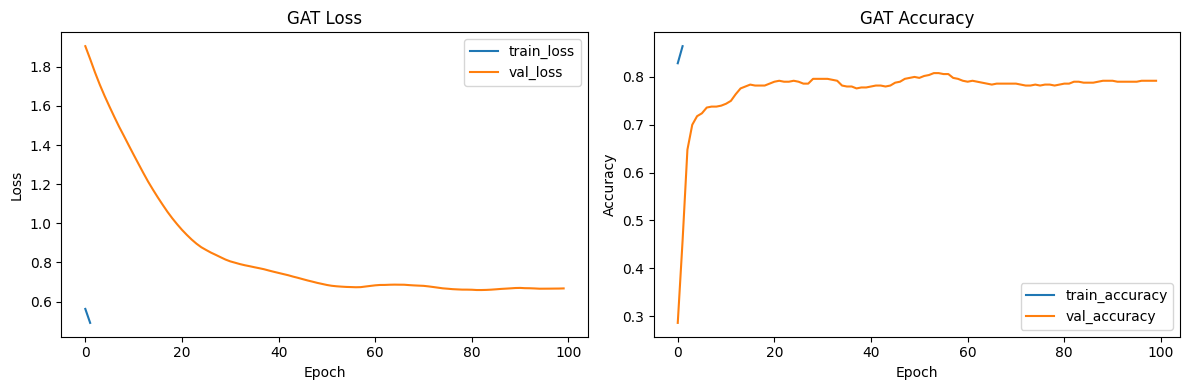

In [18]:
metrics_gat = pd.read_csv(f"{trainer_gat.logger.log_dir}/metrics.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(metrics_gat["loss"].dropna().values, label="train_loss")
axes[0].plot(metrics_gat["val_loss"].dropna().values, label="val_loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].set_title("GAT Loss")

axes[1].plot(metrics_gat["accuracy"].dropna().values, label="train_accuracy")
axes[1].plot(metrics_gat["val_accuracy"].dropna().values, label="val_accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].set_title("GAT Accuracy")

plt.tight_layout()
plt.show()

## GraphSAGE

**GraphSAGE** (SAmple and aggreGatE), introduced by Hamilton et al. (2017), is another important GNN architecture that differs from GCN in two key ways:

1. It **samples** a fixed number of neighbors rather than using all of them, making it scalable to very large graphs
2. It **concatenates** the node's own representation with the aggregated neighbor representation, rather than simply summing them

The update rule for a GraphSAGE layer is:

$$\mathbf{h}_v^{(l)} = \sigma\left(\mathbf{W}^{(l)} \cdot [\mathbf{h}_v^{(l-1)} \| \text{AGG}(\{\mathbf{h}_u^{(l-1)}, \forall u \in \mathcal{N}(v)\})]\right)$$

where AGG can be mean, max pooling, or an LSTM aggregator.

Let's build a GraphSAGE model.

In [19]:
from torch_geometric.nn import SAGEConv

class GraphSAGEModel(BaseGNNModule):
    def __init__(self, num_features, num_hidden, num_classes, dropout=0.5, lr=0.01, weight_decay=5e-4):
        super().__init__(lr=lr, weight_decay=weight_decay)
        self.dropout = dropout
        self.conv1 = SAGEConv(num_features, num_hidden)
        self.conv2 = SAGEConv(num_hidden, num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

sage_model = GraphSAGEModel(
    num_features=dataset.num_features,
    num_hidden=16,
    num_classes=dataset.num_classes
)
print(sage_model)

total_params = sum(p.numel() for p in sage_model.parameters())
print(f"\nTotal parameters: {total_params:,}")

GraphSAGEModel(
  (train_accuracy): MulticlassAccuracy()
  (val_accuracy): MulticlassAccuracy()
  (test_accuracy): MulticlassAccuracy()
  (conv1): SAGEConv(1433, 16, aggr=mean)
  (conv2): SAGEConv(16, 7, aggr=mean)
)

Total parameters: 46,103


Let's train the GraphSAGE model.

In [20]:
trainer_sage = L.Trainer(max_epochs=100, accelerator="gpu" if torch.cuda.is_available() else "cpu", devices=1)
trainer_sage.fit(model=sage_model, datamodule=cora_dm)

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/aalgahmi/torch/lib/python3.13/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name           | Type               | Params | Mode 
--------------------------------------------------------------
0 | train_accuracy | MulticlassAccuracy | 0      | train
1 | val_accuracy   | MulticlassAccuracy | 0      | train
2 | test_accuracy  | MulticlassAccuracy | 0      | train
3 | conv1          | SAGEConv           | 45.9 K | train
4 | conv2          | SAGEConv           | 231    | train
--------------------------------------------------------------
46.1 K    Trainable params
0         Non-trainable params
46.1 K    Total params
0.184     Total estimated mo

/Users/aalgahmi/torch/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/Users/aalgahmi/torch/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/Users/aalgahmi/torch/lib/python3.13/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 0: 100%|█| 1/1 [00:00<00:00, 100.58it/s, v_num=16, loss=1.950, accuracy=0.
Validation: |                                             | 0/? [00:00<?, ?it/s]
Validation DataLoader 0: 100%|███████████████████| 1/1 [00:00<00:00, 147.56it/s]
Epoch 1: 100%|█| 1/1 [00:00<00:00, 48.85it/s, v_num=16, loss=1.820, accuracy=0.4
Validation: |                                             | 0/? [00:00<?, ?it/s]
Validation DataLoader 0: 100%|███████████████████| 1/1 [00:00<00:00, 144.45it/s]
Epoch 2: 100%|█| 1/1 [00:00<00:00, 126.97it/s, v_num=16, loss=1.620, accuracy=0.
Validation: |                                             | 0/? [00:00<?, ?it/s]
Validation DataLoader 0: 100%|███████████████████| 1/1 [00:00<00:00, 149.75it/s]
Epoch 3: 100%|█| 1/1 [00:00<00:00, 129.28it/s, v_num=16, loss=1.450, accuracy=0.
Validation: |                                             | 0/? [00:00<?, ?it/s]
Validation DataLoader 0: 100%|███████████████████| 1/1 [00:00<00:00, 151.17it/s]
Epoch 4: 100%|█| 1/1 [00:00<

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|█| 1/1 [00:00<00:00, 40.29it/s, v_num=16, loss=0.0182, accuracy=1


In [21]:
trainer_sage.test(sage_model, datamodule=cora_dm)

/Users/aalgahmi/torch/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████████████████| 1/1 [00:00<00:00, 116.58it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      test_accuracy         0.7990000247955322
        test_loss           0.6481434106826782
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.6481434106826782, 'test_accuracy': 0.7990000247955322}]

### Visualizing Learned Node Embeddings

One of the most insightful ways to evaluate a GNN is to visualize the learned node embeddings. If the GNN has learned meaningful representations, nodes of the same class should cluster together in the embedding space.

Let's extract the embeddings from the second-to-last layer of our GCN model and visualize them using t-SNE.

/Users/aalgahmi/torch/lib/python3.13/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/aalgahmi/torch/lib/python3.13/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/aalgahmi/torch/lib/python3.13/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/aalgahmi/torch/lib/python3.13/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/aalgahmi/torch/lib/python3.13/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/aalgahmi/torch/lib/python3.13/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/aalgahmi/torch/lib/python3.13/site-

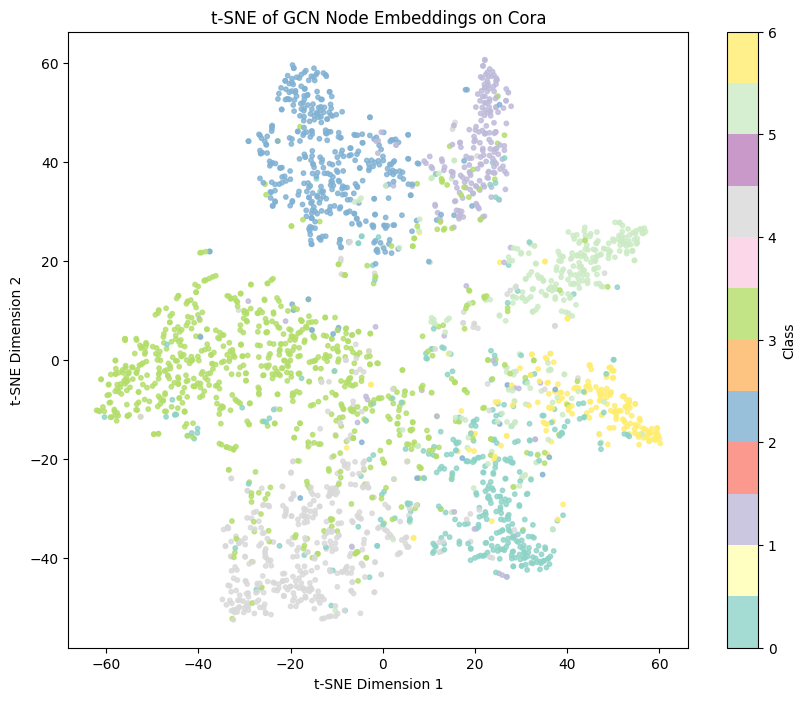

In [22]:
from sklearn.manifold import TSNE

# Get embeddings from the GCN model (after the first layer)
gcn_model.eval()
with torch.no_grad():
    x = data.x
    edge_index = data.edge_index
    x = gcn_model.conv1(x, edge_index)
    embeddings = F.relu(x).numpy()

# Apply t-SNE to reduce to 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings)

# Plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                      c=data.y.numpy(), cmap='Set3', s=10, alpha=0.8)
plt.colorbar(scatter, label='Class')
plt.title("t-SNE of GCN Node Embeddings on Cora")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()

The clear separation of clusters confirms that the GCN has learned to map papers of the same research topic to similar regions in the embedding space.

## Graph Classification

So far, we have been classifying individual **nodes** within a single graph. Another important task is **graph classification**, where the goal is to predict a label for an entire graph. This is common in molecular property prediction (e.g., is this molecule toxic?), protein function prediction, and social network analysis.

For graph classification, we need an additional step: after message passing produces node-level embeddings, we must **pool** (or readout) these embeddings into a single graph-level representation. Common pooling strategies include:

- **Global mean pooling**: $\mathbf{h}_G = \frac{1}{|V|} \sum_{v \in V} \mathbf{h}_v^{(K)}$
- **Global max pooling**: $\mathbf{h}_G = \max_{v \in V} \mathbf{h}_v^{(K)}$
- **Global add pooling**: $\mathbf{h}_G = \sum_{v \in V} \mathbf{h}_v^{(K)}$

### The MUTAG Dataset

We will use the **MUTAG** dataset, a well-known benchmark for graph classification. MUTAG contains 188 molecular graphs, where:
- Each **graph** represents a chemical compound
- Each **node** is an atom with a 7-dimensional feature vector (one-hot encoding of atom type)
- Each **edge** is a chemical bond
- The task is to predict whether the molecule has a **mutagenic effect** on bacteria (binary classification)

Let's load and explore this dataset.

In [23]:
from torch_geometric.datasets import TUDataset

mutag_dataset = TUDataset(root='./datasets', name='MUTAG')

print(f"Dataset: {mutag_dataset}")
print(f"Number of graphs: {len(mutag_dataset)}")
print(f"Number of features: {mutag_dataset.num_features}")
print(f"Number of classes: {mutag_dataset.num_classes}")

# Look at the first few graphs
for i in range(3):
    g = mutag_dataset[i]
    print(f"\nGraph {i}: {g}")
    print(f"  Nodes: {g.num_nodes}, Edges: {g.num_edges}, Label: {g.y.item()}")

Dataset: MUTAG(188)
Number of graphs: 188
Number of features: 7
Number of classes: 2

Graph 0: Data(edge_index=[2, 38], x=[17, 7], edge_attr=[38, 4], y=[1])
  Nodes: 17, Edges: 38, Label: 1

Graph 1: Data(edge_index=[2, 28], x=[13, 7], edge_attr=[28, 4], y=[1])
  Nodes: 13, Edges: 28, Label: 0

Graph 2: Data(edge_index=[2, 28], x=[13, 7], edge_attr=[28, 4], y=[1])
  Nodes: 13, Edges: 28, Label: 0


Let's visualize a couple of molecules from the dataset.

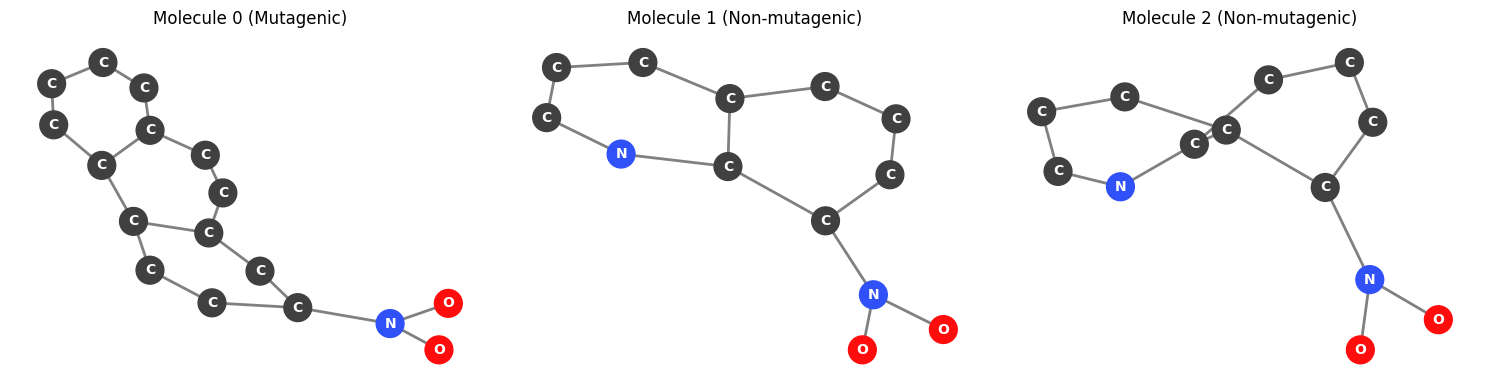

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

atom_types = ['C', 'N', 'O', 'F', 'I', 'Cl', 'Br']
colors = ['#404040', '#3050F8', '#FF0D0D', '#90E050', '#940094', '#1FF01F', '#A62929']

for idx, ax in enumerate(axes):
    g = mutag_dataset[idx]
    G = to_networkx(g, to_undirected=True)

    # Color nodes by atom type
    node_colors = [colors[g.x[n].argmax().item()] for n in range(g.num_nodes)]
    node_labels = {n: atom_types[g.x[n].argmax().item()] for n in range(g.num_nodes)}

    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, ax=ax, node_color=node_colors, labels=node_labels,
            node_size=400, font_size=10, font_color='white', font_weight='bold',
            edge_color='gray', width=2)
    label_text = "Mutagenic" if g.y.item() == 1 else "Non-mutagenic"
    ax.set_title(f"Molecule {idx} ({label_text})")

plt.tight_layout()
plt.show()

### Preparing the Data

Unlike the Cora example where we had a single graph, here we have a dataset of many individual graphs. We need to split them into train and test sets and create data loaders that properly batch multiple graphs together. PyG's `DataLoader` handles this automatically by creating a single large disconnected graph for each batch.

In [25]:
from torch_geometric.loader import DataLoader as PyGDataLoader

# Shuffle and split the dataset
torch.manual_seed(42)
mutag_dataset = mutag_dataset.shuffle()

train_size = int(0.8 * len(mutag_dataset))
train_dataset = mutag_dataset[:train_size]
test_dataset = mutag_dataset[train_size:]

print(f"Training graphs: {len(train_dataset)}")
print(f"Test graphs: {len(test_dataset)}")

train_loader = PyGDataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = PyGDataLoader(test_dataset, batch_size=32, shuffle=False)

Training graphs: 150
Test graphs: 38


**IMPORTANT**: When batching multiple graphs, PyG concatenates all nodes and edges into a single large graph and maintains a `batch` vector that maps each node to its original graph. This `batch` vector is critical for graph-level pooling.

In [26]:
# Let's see what a batch looks like
for batch in train_loader:
    print(f"Batch: {batch}")
    print(f"Number of graphs in batch: {batch.num_graphs}")
    print(f"Batch vector shape: {batch.batch.shape}")
    print(f"Batch vector (first 50): {batch.batch[:50]}")
    break

Batch: DataBatch(edge_index=[2, 1202], x=[550, 7], edge_attr=[1202, 4], y=[32], batch=[550], ptr=[33])
Number of graphs in batch: 32
Batch vector shape: torch.Size([550])
Batch vector (first 50): tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3])


### Building a Graph Classification Model

For graph classification, we build a GNN that:
1. Applies multiple GCN layers for message passing
2. Uses **global mean pooling** to aggregate node embeddings into a graph-level representation
3. Passes the graph-level representation through a classifier (fully connected layers)

In [27]:
from torch_geometric.nn import GCNConv, global_mean_pool

class GraphClassifier(L.LightningModule):
    def __init__(self, num_features, num_hidden, num_classes, lr=0.01):
        super().__init__()
        self.lr = lr
        self.train_accuracy = Accuracy(task="binary")
        self.val_accuracy = Accuracy(task="binary")
        self.test_accuracy = Accuracy(task="binary")

        # GNN layers
        self.conv1 = GCNConv(num_features, num_hidden)
        self.conv2 = GCNConv(num_hidden, num_hidden)
        self.conv3 = GCNConv(num_hidden, num_hidden)

        # Classifier
        self.lin = nn.Linear(num_hidden, num_classes)

    def forward(self, x, edge_index, batch):
        # Message passing
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.conv3(x, edge_index)

        # Global pooling: aggregate node embeddings into graph embeddings
        x = global_mean_pool(x, batch)  # [batch_size, num_hidden]

        # Classify
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)
        return x

    def training_step(self, batch, batch_idx):
        logits = self(batch.x, batch.edge_index, batch.batch)
        loss = F.cross_entropy(logits, batch.y)
        y_hat = logits.argmax(dim=-1)
        self.log("loss", loss, prog_bar=True, batch_size=batch.num_graphs)
        self.log("accuracy", self.train_accuracy(y_hat, batch.y), prog_bar=True, batch_size=batch.num_graphs)
        return loss

    def on_train_epoch_end(self):
        self.log("train_accuracy", self.train_accuracy.compute())
        self.train_accuracy.reset()

    def test_step(self, batch, batch_idx):
        logits = self(batch.x, batch.edge_index, batch.batch)
        loss = F.cross_entropy(logits, batch.y)
        y_hat = logits.argmax(dim=-1)
        self.log("test_loss", loss, batch_size=batch.num_graphs)
        self.log("test_accuracy", self.test_accuracy(y_hat, batch.y), batch_size=batch.num_graphs)
        return loss

    def on_test_epoch_end(self):
        self.log("test_accuracy", self.test_accuracy.compute())
        self.test_accuracy.reset()

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

graph_model = GraphClassifier(
    num_features=mutag_dataset.num_features,
    num_hidden=64,
    num_classes=mutag_dataset.num_classes
)
print(graph_model)

total_params = sum(p.numel() for p in graph_model.parameters())
print(f"\nTotal parameters: {total_params:,}")

GraphClassifier(
  (train_accuracy): BinaryAccuracy()
  (val_accuracy): BinaryAccuracy()
  (test_accuracy): BinaryAccuracy()
  (conv1): GCNConv(7, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)

Total parameters: 8,962


We are now ready to train the graph classification model.

In [28]:
trainer_graph = L.Trainer(max_epochs=100, accelerator="gpu" if torch.cuda.is_available() else "cpu", devices=1)
trainer_graph.fit(model=graph_model, train_dataloaders=train_loader)

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/aalgahmi/torch/lib/python3.13/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name           | Type           | Params | Mode 
----------------------------------------------------------
0 | train_accuracy | BinaryAccuracy | 0      | train
1 | val_accuracy   | BinaryAccuracy | 0      | train
2 | test_accuracy  | BinaryAccuracy | 0      | train
3 | conv1          | GCNConv        | 512    | train
4 | conv2          | GCNConv        | 4.2 K  | train
5 | conv3          | GCNConv        | 4.2 K  | train
6 | lin            | Linear         | 130    | train
----------------------------------------------------------
9.0 K     Trainable params
0       

Epoch 99: 100%|█| 5/5 [00:00<00:00, 309.00it/s, v_num=17, loss=0.370, accuracy=0

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|█| 5/5 [00:00<00:00, 268.40it/s, v_num=17, loss=0.370, accuracy=0


Let's evaluate on the test set.

In [29]:
trainer_graph.test(graph_model, dataloaders=test_loader)

/Users/aalgahmi/torch/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████████████████| 2/2 [00:00<00:00, 251.38it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      test_accuracy         0.6842105388641357
        test_loss           0.7382028698921204
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.7382028698921204, 'test_accuracy': 0.6842105388641357}]

Here are the training curves.

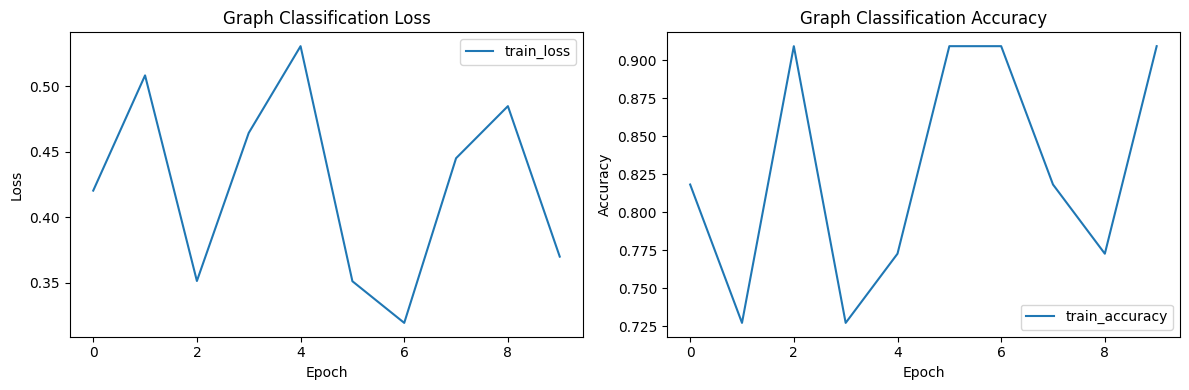

In [30]:
metrics_graph = pd.read_csv(f"{trainer_graph.logger.log_dir}/metrics.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(metrics_graph["loss"].dropna().values, label="train_loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].set_title("Graph Classification Loss")

axes[1].plot(metrics_graph["accuracy"].dropna().values, label="train_accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].set_title("Graph Classification Accuracy")

plt.tight_layout()
plt.show()

## Comparing Pooling Strategies

In graph classification, a GNN produces a vector (embedding) for each node after several rounds of message passing. But to classify the *entire graph*, we need a single fixed-size vector that summarizes all of those node embeddings — regardless of how many nodes the graph has. This is the job of **global graph pooling** (also called readout).

The three most common strategies are **global mean pooling**, which averages all node embeddings and works well when the overall distribution of node features matters; **global max pooling**, which takes the element-wise maximum and is good at picking out the most prominent feature present anywhere in the graph; and **global sum pooling**, which sums all embeddings and naturally encodes graph *size* information alongside structure. No single strategy is universally best — mean pooling tends to generalize well on noisy data, max pooling excels when a single distinctive sub-structure determines the label, and sum pooling can be advantageous when graph size itself is a discriminative signal. Comparing them is therefore a standard first step when tackling a new graph classification problem.

The choice of pooling strategy can significantly affect graph classification performance. Let's compare all three on the MUTAG task.

In [31]:
from torch_geometric.nn import global_mean_pool, global_max_pool, global_add_pool

class GraphClassifierWithPooling(L.LightningModule):
    def __init__(self, num_features, num_hidden, num_classes, pool_fn, pool_name, lr=0.01):
        super().__init__()
        self.lr = lr
        self.pool_fn = pool_fn
        self.pool_name = pool_name
        self.test_accuracy = Accuracy(task="binary")

        self.conv1 = GCNConv(num_features, num_hidden)
        self.conv2 = GCNConv(num_hidden, num_hidden)
        self.conv3 = GCNConv(num_hidden, num_hidden)
        self.lin = nn.Linear(num_hidden, num_classes)

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = self.conv3(x, edge_index)
        x = self.pool_fn(x, batch)
        x = F.dropout(x, p=0.5, training=self.training)
        return self.lin(x)

    def training_step(self, batch, batch_idx):
        logits = self(batch.x, batch.edge_index, batch.batch)
        return F.cross_entropy(logits, batch.y)

    def test_step(self, batch, batch_idx):
        logits = self(batch.x, batch.edge_index, batch.batch)
        y_hat = logits.argmax(dim=-1)
        self.test_accuracy(y_hat, batch.y)

    def on_test_epoch_end(self):
        self.log("test_accuracy", self.test_accuracy.compute())
        self.test_accuracy.reset()

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

# Train and evaluate with each pooling strategy
pool_strategies = [
    (global_mean_pool, "Mean Pooling"),
    (global_max_pool, "Max Pooling"),
    (global_add_pool, "Sum Pooling"),
]

results = {}
for pool_fn, pool_name in pool_strategies:
    model = GraphClassifierWithPooling(
        num_features=mutag_dataset.num_features,
        num_hidden=64,
        num_classes=mutag_dataset.num_classes,
        pool_fn=pool_fn,
        pool_name=pool_name
    )
    trainer = L.Trainer(max_epochs=100, accelerator="gpu" if torch.cuda.is_available() else "cpu",
                        devices=1, enable_progress_bar=False)
    trainer.fit(model, train_dataloaders=train_loader)
    test_result = trainer.test(model, dataloaders=test_loader, verbose=False)
    results[pool_name] = test_result[0]["test_accuracy"]
    print(f"{pool_name}: Test Accuracy = {results[pool_name]:.4f}")

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/aalgahmi/torch/lib/python3.13/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name          | Type           | Params | Mode 
---------------------------------------------------------
0 | test_accuracy | BinaryAccuracy | 0      | train
1 | conv1         | GCNConv        | 512    | train
2 | conv2         | GCNConv        | 4.2 K  | train
3 | conv3         | GCNConv        | 4.2 K  | train
4 | lin           | Linear         | 130    | train
---------------------------------------------------------
9.0 K     Trainable params
0         Non-trainable params
9.0 K     Total params
0.036     Total estimated model params size (MB)
11        Modules i

Mean Pooling: Test Accuracy = 0.6842


`Trainer.fit` stopped: `max_epochs=100` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name          | Type           | Params | Mode 
---------------------------------------------------------
0 | test_accuracy | BinaryAccuracy | 0      | train
1 | conv1         | GCNConv        | 512    | train
2 | conv2         | GCNConv        | 4.2 K  | train
3 | conv3         | GCNConv        | 4.2 K  | train
4 | lin           | Linear         | 130    | train
---------------------------------------------------------
9.0 K     Trainable params
0         Non-trainable params
9.0 K     Total params
0.036     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode


Max Pooling: Test Accuracy = 0.7105


`Trainer.fit` stopped: `max_epochs=100` reached.


Sum Pooling: Test Accuracy = 0.6579


Let's visualize the comparison.

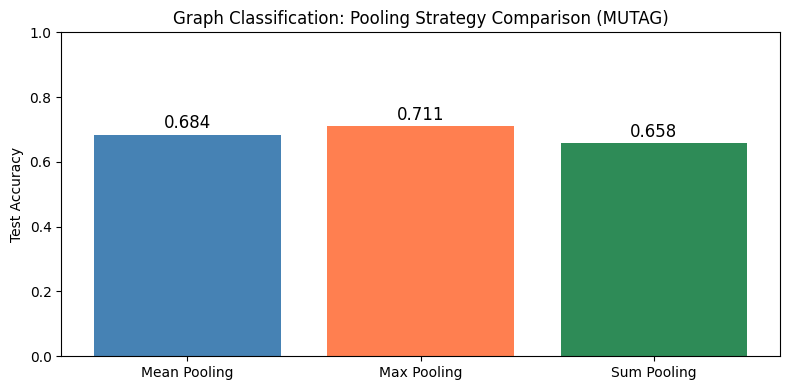

In [32]:
plt.figure(figsize=(8, 4))
bars = plt.bar(results.keys(), results.values(), color=['steelblue', 'coral', 'seagreen'])
plt.ylabel("Test Accuracy")
plt.title("Graph Classification: Pooling Strategy Comparison (MUTAG)")
plt.ylim(0, 1.0)

for bar, acc in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
             f"{acc:.3f}", ha='center', fontsize=12)

plt.tight_layout()
plt.show()

## Graph Classification on the PROTEINS Dataset

The **PROTEINS** dataset is another well-known benchmark from the TUDataset collection. Each graph represents a **protein**, where:

- **Nodes** are secondary structure elements (SSEs) — alpha-helices, beta-sheets, and coils.
- **Edges** connect SSEs that are adjacent in the amino-acid sequence or in 3D space.
- **Node features** consist of 3 continuous attributes (physicochemical properties).
- **Labels** indicate whether the protein is an **enzyme** (class 1) or **non-enzyme** (class 0).

With 1,113 proteins and an average of ~39 nodes per graph, PROTEINS is a manageable but meaningful benchmark for graph-level classification.

Since each protein graph contains tens of nodes on average, we can convert them to NetworkX graphs and draw them just like we did with molecules in the MUTAG example. Node colors can reflect node labels (SSE types).

In [33]:
from torch_geometric.datasets import TUDataset

proteins_dataset = TUDataset(root='./datasets', name='PROTEINS')

print(f"Dataset: {proteins_dataset}")
print(f"Number of graphs : {len(proteins_dataset)}")
print(f"Number of classes: {proteins_dataset.num_classes}")
print(f"Number of node features: {proteins_dataset.num_node_features}")
print()

# Summary stats across graphs
num_nodes = [g.num_nodes for g in proteins_dataset]
num_edges = [g.num_edges for g in proteins_dataset]
labels    = [g.y.item() for g in proteins_dataset]

print(f"Nodes per graph  — min: {min(num_nodes)}, max: {max(num_nodes)}, avg: {sum(num_nodes)/len(num_nodes):.1f}")
print(f"Edges per graph  — min: {min(num_edges)}, max: {max(num_edges)}, avg: {sum(num_edges)/len(num_edges):.1f}")
print(f"Class distribution — enzymes: {sum(labels)}, non-enzymes: {len(labels)-sum(labels)}")

Dataset: PROTEINS(1113)
Number of graphs : 1113
Number of classes: 2
Number of node features: 3

Nodes per graph  — min: 4, max: 620, avg: 39.1
Edges per graph  — min: 10, max: 2098, avg: 145.6
Class distribution — enzymes: 450, non-enzymes: 663


### Visualizing Protein Graphs with NetworkX

Each protein is a small graph. We can visualize a few examples to see how their topology differs between enzymes and non-enzymes. Node color encodes the discrete node label (SSE type: 0 = beta-sheet, 1 = helix/coil), and node size reflects the degree (number of connections).

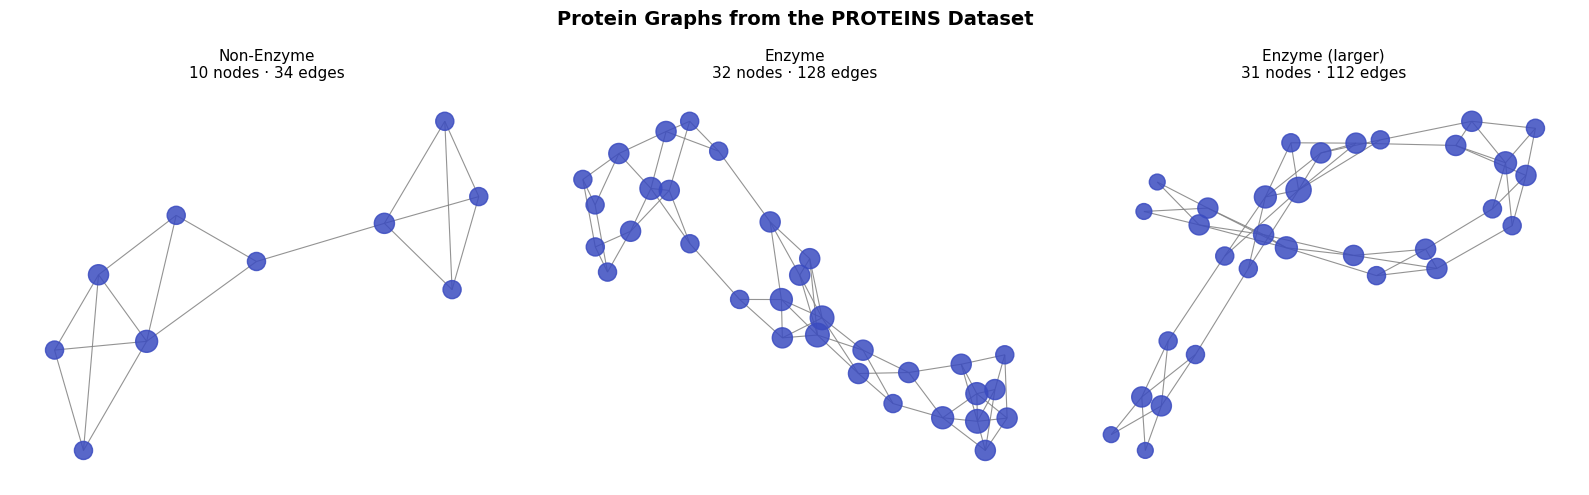

In [34]:
import networkx as nx
from torch_geometric.utils import to_networkx

# Pick one enzyme and one non-enzyme for comparison
enzyme_graphs     = [g for g in proteins_dataset if g.y.item() == 1]
non_enzyme_graphs = [g for g in proteins_dataset if g.y.item() == 0]

# Choose three examples: small, medium, and larger
examples = [
    (non_enzyme_graphs[2],  "Non-Enzyme"),
    (enzyme_graphs[0],      "Enzyme"),
    (enzyme_graphs[5],      "Enzyme (larger)"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Protein Graphs from the PROTEINS Dataset", fontsize=14, fontweight='bold')

for ax, (graph, label) in zip(axes, examples):
    G = to_networkx(graph, to_undirected=True)
    
    # Node colors: use discrete node label if available, else degree
    if graph.x is not None:
        # The last feature column is a binary SSE-type indicator
        node_colors = graph.x[:, -1].tolist()
    else:
        node_colors = [0] * graph.num_nodes

    degrees  = dict(G.degree())
    node_sizes = [50 + degrees[n] * 40 for n in G.nodes()]

    pos = nx.spring_layout(G, seed=42)
    nx.draw_networkx(
        G, pos=pos, ax=ax,
        node_color=node_colors, cmap=plt.cm.coolwarm,
        node_size=node_sizes,
        with_labels=False, edge_color='gray', alpha=0.85, width=0.8
    )
    ax.set_title(f"{label}\n{graph.num_nodes} nodes · {graph.num_edges} edges", fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

The graphs clearly differ in topology: enzyme graphs tend to be denser with more interconnected secondary structure elements, while non-enzymes are often sparser. This structural signal is exactly what a GNN can learn to exploit for classification.

In [35]:
# Shuffle and split PROTEINS (80 / 10 / 10)
torch.manual_seed(42)
perm = torch.randperm(len(proteins_dataset))

n_train = int(0.8 * len(proteins_dataset))
n_val   = int(0.1 * len(proteins_dataset))

proteins_train = proteins_dataset[perm[:n_train]]
proteins_val   = proteins_dataset[perm[n_train:n_train + n_val]]
proteins_test  = proteins_dataset[perm[n_train + n_val:]]

proteins_train_loader = PyGDataLoader(proteins_train, batch_size=32, shuffle=True)
proteins_val_loader   = PyGDataLoader(proteins_val,   batch_size=64)
proteins_test_loader  = PyGDataLoader(proteins_test,  batch_size=64)

print(f"Train: {len(proteins_train)} | Val: {len(proteins_val)} | Test: {len(proteins_test)}")

Train: 890 | Val: 111 | Test: 112


### Training a GNN on PROTEINS

We reuse the `GraphClassifierWithPooling` class from the pooling-strategy comparison above, but configure it for the PROTEINS dataset (3 node features, 2 output classes). We will compare all three pooling strategies.

In [36]:
proteins_results = {}

for pool_fn, pool_name in [(global_mean_pool, "Mean Pooling"),
                            (global_max_pool,  "Max Pooling"),
                            (global_add_pool,  "Sum Pooling")]:
    model = GraphClassifierWithPooling(
        num_features=proteins_dataset.num_node_features,
        num_hidden=64,
        num_classes=proteins_dataset.num_classes,
        pool_fn=pool_fn,
        pool_name=pool_name
    )

    trainer_p = L.Trainer(
        max_epochs=100,
        accelerator="gpu" if torch.cuda.is_available() else "cpu",
        devices=1,
        enable_progress_bar=False,
        enable_model_summary=False,
        logger=True
    )
    trainer_p.fit(model,
                  train_dataloaders=proteins_train_loader,
                  val_dataloaders=proteins_val_loader)

    results_p = trainer_p.test(model, dataloaders=proteins_test_loader, verbose=False)
    acc = results_p[0]["test_accuracy"]
    proteins_results[pool_name] = acc
    print(f"{pool_name:>15}  ->  Test Accuracy: {acc:.4f}")

print()
best = max(proteins_results, key=proteins_results.get)
print(f"Best pooling strategy: {best} ({proteins_results[best]:.4f})")

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/aalgahmi/torch/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
/Users/aalgahmi/torch/lib/python3.13/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (28) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
`Trainer.fit` stopped: `max_epochs=100` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available:

   Mean Pooling  ->  Test Accuracy: 0.7232


`Trainer.fit` stopped: `max_epochs=100` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


    Max Pooling  ->  Test Accuracy: 0.8393


`Trainer.fit` stopped: `max_epochs=100` reached.


    Sum Pooling  ->  Test Accuracy: 0.7768

Best pooling strategy: Max Pooling (0.8393)


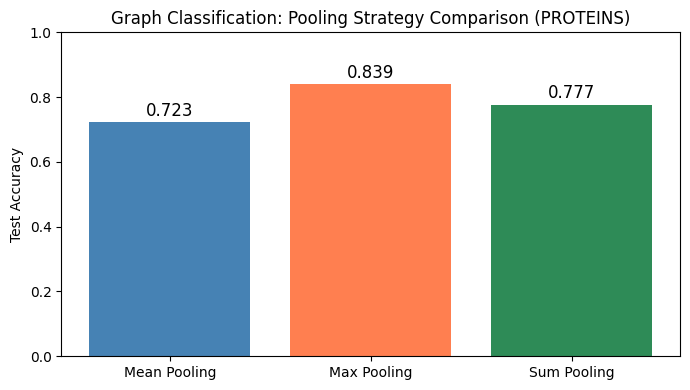

In [37]:
plt.figure(figsize=(7, 4))
bars = plt.bar(proteins_results.keys(), proteins_results.values(),
               color=["steelblue", "coral", "seagreen"])
plt.ylabel("Test Accuracy")
plt.title("Graph Classification: Pooling Strategy Comparison (PROTEINS)")
plt.ylim(0, 1.0)

for bar, acc in zip(bars, proteins_results.values()):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
             f"{acc:.3f}", ha="center", fontsize=12)

plt.tight_layout()
plt.show()

## Summary of GNN Architectures

Here is a quick comparison of the GNN architectures we covered in this notebook:

| Architecture | Aggregation | Key Idea | Strengths |
| --- | --- | --- | --- |
| **GCN** | Normalized sum | Fixed weights based on degree | Simple, effective baseline |
| **GAT** | Attention-weighted sum | Learned neighbor importance | Flexible, interpretable |
| **GraphSAGE** | Mean/Max/LSTM | Sample + concatenate | Scalable to large graphs |

All of these architectures follow the message passing framework and can be applied to both node-level and graph-level tasks. The choice between them depends on the specific problem, graph size, and whether interpretability (attention weights) is important.

Feel free to experiment with different hyperparameters, number of layers, hidden dimensions, and pooling strategies. You might also try other datasets available in PyTorch Geometric, such as `CiteSeer` or `PubMed`.

Happy learning!